# Vanilla PrefixMemory-Tuning (PMT) Baseline — Training and Evaluation

This notebook trains and evaluates the **Vanilla PrefixMemory-Tuning (PMT) baseline** used in the thesis.

The backbone is `meta-llama/Llama-3.1-8B-Instruct`, whose parameters remain frozen throughout training. PMT introduces a trainable external memory matrix for each transformer layer and injects the resulting memory-derived bias into the self-attention output.

Unlike the CEFR-conditioned PMT variants proposed in the thesis, this baseline contains **no CEFR-specific embedding, gating mechanism, or architectural control knob**. CEFR information is therefore supplied only through the textual instruction.

Training uses the **Balanced CEFR Steering Subset**, containing 5,568 examples with equal representation across A1–C2. A stratified 90/10 train-validation split is applied with `random_state=42`.

The notebook includes:

- Vanilla PMT controller construction;
- training and validation with the causal language-modeling objective;
- hardware profiling;
- publication of the trained PMT controller to Hugging Face;
- generation on the final In-Domain Evaluation Prompt Matrix;
- evaluation with the primary Joint-Loss CEFR evaluator;
- CEFR-control and linguistic diagnostic metrics.

The final PMT baseline is evaluated on the same 702-condition in-domain benchmark used for the other control methods.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers torch datasets huggingface_hub accelerate hf_transfer "torchao>=0.16.0" nvidia-ml-py

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import json
import math
import time
import threading
import pynvml
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup,
    set_seed
)
from huggingface_hub import login, HfApi
from google.colab import drive, userdata
from tqdm.auto import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.5 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Ensure strict reproducibility
set_seed(42)
torch.backends.cudnn.deterministic = True

# Mount Google Drive
drive.mount('/content/drive')

# Configuration Paths - Vanilla PMT 6k Baseline (Training Only)
BALANCED_CSV_PATH = "/content/drive/MyDrive/Your_Path/balanced_cefr_steering_subset.csv"
DRIVE_LOG_DIR = "/content/drive/MyDrive/Your_Path/vanilla_pmt_training_logs"
LOCAL_OUTPUT_DIR = "./pure_pmt_6k_hf_export"
HF_REPO_ID = "MohammadKhosravi/llama3.1-8b-pure-pmt-6k"

os.makedirs(DRIVE_LOG_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

# Authentication
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Using execution device: cuda
Device Name: NVIDIA A100-SXM4-80GB


In [ ]:
# ==========================================
# 1. INGEST BALANCED DATASET (6k STRATIFIED SPLIT)
# ==========================================
print(f"\n📥 Ingesting pre-balanced topic-aligned dataset from: {BALANCED_CSV_PATH}")
balanced_df = pd.read_csv(BALANCED_CSV_PATH).dropna(subset=['cefr', 'clean_text', 'topic_title'])
balanced_df['cefr'] = balanced_df['cefr'].str.upper().str.strip()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
balanced_df['cefr_id'] = balanced_df['cefr'].map(label_map)
balanced_df = balanced_df.dropna(subset=['cefr_id'])
balanced_df['cefr_id'] = balanced_df['cefr_id'].astype(int)

# Stratified 90/10 Split
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.10,
    stratify=balanced_df['cefr_id'],
    random_state=42
)

print(f"Training partition size:   {len(train_df):,} samples")
print(f"Validation partition size: {len(val_df):,} samples")


📥 Ingesting pre-balanced topic-aligned dataset from: /content/drive/MyDrive/Mohammd_Thesis/subsets/efcamdat_balanced_subset_training.csv
Training partition size:   5,011 samples
Validation partition size: 557 samples


In [ ]:
# ==========================================
# 2. LOAD FROZEN BASE LLM & TOKENIZER
# ==========================================
print("\nLoading Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Right padding is required for causal language modeling during training
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load safely on CUDA
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": torch.cuda.current_device()}
)

# Strictly freeze the base Llama backbone
for param in base_model.parameters():
    param.requires_grad = False
base_model.eval()
base_model.config.use_cache = False

# ==========================================
# 3. VANILLA PREFIXMEMORY-TUNING (PMT) ARCHITECTURE
# ==========================================
class PurePMTController(nn.Module):
    """
    Standard PrefixMemory-Tuning (Wang et al., 2026).
    The prefix module is shifted out of the attention head, replacing softmax regularization tradeoffs
    by an external memory module (M) and a feature map approximation computed over the Query (Q).

    This implementation explicitly uses a full [num_layers, hidden_dim, hidden_dim] memory tensor.
    """
    def __init__(self, num_layers=32, hidden_dim=4096):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Pure PMT Memory Matrices: Shape [32, 4096, 4096] (~536.8 Million Parameters)
        self.M = nn.Parameter(torch.randn(num_layers, hidden_dim, hidden_dim) * (hidden_dim ** -0.5))

# Llama-3.1-8B dimensions
prefix_memory_controller = PurePMTController(num_layers=32, hidden_dim=4096).to(device).to(torch.bfloat16)

def make_pure_pmt_hook(layer_idx):
    def hook_fn(module, args, kwargs, output):
        # Extract hidden states entering the self-attention layer
        if len(args) > 0:
            hidden_states = args[0]
        elif 'hidden_states' in kwargs:
            hidden_states = kwargs['hidden_states']
        else:
            return output

        attn_output = output[0] # [Batch, Seq, 4096]

        # 1. Compute Queries (Q) dynamically using the frozen self-attention q_proj layer
        Q = module.q_proj(hidden_states) # [Batch, Seq, 4096]

        # 2. Apply Feature Map directly to the full-dimensional Query
        phi_Q = F.elu(Q) # [Batch, Seq, 4096]

        # 3. Retrieve Layer Memory Matrix: [4096, 4096]
        M_l = prefix_memory_controller.M[layer_idx]

        # 4. Multiply: phi(Q) @ M -> [Batch, Seq, 4096]
        prefix_memory_bias = torch.matmul(phi_Q, M_l)

        # 5. Injection (Scaling factor alpha absorbed into M as per Wang et al., 2026)
        final_attn_output = attn_output + prefix_memory_bias

        return (final_attn_output,) + output[1:]
    return hook_fn

# Register the Vanilla PMT forward hooks on all 32 self-attention layers
for i in range(32):
    base_model.model.layers[i].self_attn.register_forward_hook(make_pure_pmt_hook(i), with_kwargs=True)

trainable_params = sum(p.numel() for p in prefix_memory_controller.parameters() if p.requires_grad)
print(f"PMT Trainable Parameters: {trainable_params:,} ({trainable_params / 1e6:.2f}M)")



Loading Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

PMT Trainable Parameters: 536,870,912 (536.87M)


In [ ]:
# ==========================================
# 4. TOPIC-ALIGNED DATA LOADER & RIGOROUS MASKING
# ==========================================
class CEFRTopicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t_cefr = str(row['cefr']).strip().upper()
        topic_title = str(row['topic_title']).strip()

        # Vanilla PMT requires explicit CEFR prompting since it lacks the architectural knob
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{topic_title}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )

        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = formatted_prompt + str(row['clean_text']).strip() + self.tokenizer.eos_token

        # Isolate prompt length exactly by utilizing add_special_tokens=False consistency
        prompt_enc = self.tokenizer(
            formatted_prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length
        )
        prompt_len = len(prompt_enc['input_ids'])

        full_enc = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
            padding='max_length'
        )

        input_ids = torch.tensor(full_enc['input_ids'], dtype=torch.long)
        attention_mask = torch.tensor(full_enc['attention_mask'], dtype=torch.long)

        # Rigorous Masking: clone input_ids, then mask prompt (-100) and padding (-100)
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

TRAIN_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
VAL_BATCH_SIZE = 16

train_loader = DataLoader(CEFRTopicDataset(train_df, tokenizer), batch_size=TRAIN_BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(CEFRTopicDataset(val_df, tokenizer), batch_size=VAL_BATCH_SIZE, shuffle=False, pin_memory=True)


In [ ]:
# =========================================================
# 5. HARDWARE PROFILER (BACKGROUND NVML DAEMON)
# =========================================================
class GPUMonitor(threading.Thread):
    def __init__(self, delay=1.0):
        super(GPUMonitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.utilization_rates = []
        pynvml.nvmlInit()
        self.handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    def run(self):
        while not self.stopped:
            try:
                util = pynvml.nvmlDeviceGetUtilizationRates(self.handle)
                self.utilization_rates.append(util.gpu)
            except Exception:
                pass
            time.sleep(self.delay)

    def stop(self):
        self.stopped = True
        try:
            pynvml.nvmlShutdown()
        except Exception:
            pass

    def get_avg_utilization(self):
        if not self.utilization_rates: return 0.0
        return sum(self.utilization_rates) / len(self.utilization_rates)

In [ ]:
# ==========================================
# 6. OPTIMIZATION & TRAINING LOOP
# ==========================================
epochs = 3
lr = 2e-4
optimizer = torch.optim.AdamW(prefix_memory_controller.parameters(), lr=lr, weight_decay=0.01)

total_training_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * epochs
warmup_steps = int(0.05 * total_training_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

best_val_loss = float('inf')
best_model_path = os.path.join(LOCAL_OUTPUT_DIR, "best_pure_pmt_weights.pt")
training_summary_logs = []

print("\n🚀 Launching Vanilla PrefixMemory-Tuning (PMT) Baseline...")

torch.cuda.reset_peak_memory_stats()
gpu_monitor = GPUMonitor(delay=1.0)
gpu_monitor.start()
start_time = time.perf_counter()

for epoch in range(epochs):
    prefix_memory_controller.train()
    running_train_loss = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward Pass (Hook intercepts self-attention output directly)
        outputs = base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        running_train_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(prefix_memory_controller.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({"Loss": f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}"})

    # Validation Loop
    prefix_memory_controller.eval()
    val_loss_accum = 0.0
    val_steps = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = base_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            val_loss_accum += outputs.loss.item()
            val_steps += 1

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = val_loss_accum / val_steps
    val_ppl = float(np.exp(avg_val_loss))

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train_loss, 4),
        "val_loss": round(avg_val_loss, 4),
        "val_ppl": round(val_ppl, 2)
    }
    training_summary_logs.append(epoch_metrics)

    print(f"\n📈 [Epoch {epoch+1}/{epochs}] Done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(prefix_memory_controller.state_dict(), best_model_path)
        print(f"🌟 Validation improved! New best model checkpoint locked.")

    torch.cuda.empty_cache()
    gc.collect()

gpu_monitor.stop()
end_time = time.perf_counter()

# Save training summary JSON locally and to Google Drive
json_log_path = os.path.join(DRIVE_LOG_DIR, "pure_pmt_training_summary_6k.json")
with open(json_log_path, "w") as f:
    json.dump(training_summary_logs, f, indent=4)
with open(os.path.join(LOCAL_OUTPUT_DIR, "training_summary_6k.json"), "w") as f:
    json.dump(training_summary_logs, f, indent=4)
print(f"\n📊 Detailed training summary logs saved to Drive: {json_log_path}")

total_time_seconds = end_time - start_time
total_time_hours = total_time_seconds / 3600
avg_gpu_util = gpu_monitor.get_avg_utilization()
peak_vram_gb = torch.cuda.max_memory_allocated() / (1024**3)

profiling_report = (
    "=== Vanilla PMT Hardware Profiling Report (6k Balanced Dataset) ===\n"
    f"Total training time: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)\n"
    f"Peak GPU memory: {peak_vram_gb:.2f} GB\n"
    f"Average GPU utilization: {avg_gpu_util:.1f}%\n"
)
print("\n" + profiling_report)


🚀 Launching Vanilla PrefixMemory-Tuning (PMT) Baseline...


Epoch 1/3 [Train]:   0%|          | 0/627 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]


📈 [Epoch 1/3] Done | Train Loss: 6.1827 | Val Loss: 5.5490 | Val PPL: 256.97
🌟 Validation improved! New best model checkpoint locked.


Epoch 2/3 [Train]:   0%|          | 0/627 [00:00<?, ?it/s]

Epoch 2/3 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]


📈 [Epoch 2/3] Done | Train Loss: 5.3515 | Val Loss: 5.2795 | Val PPL: 196.26
🌟 Validation improved! New best model checkpoint locked.


Epoch 3/3 [Train]:   0%|          | 0/627 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]


📈 [Epoch 3/3] Done | Train Loss: 5.1446 | Val Loss: 5.2255 | Val PPL: 185.96
🌟 Validation improved! New best model checkpoint locked.

📊 Detailed training summary logs saved to Drive: /content/drive/MyDrive/Mohammd_Thesis/Training_Logs/Pure_PMT_6k/pure_pmt_training_summary_6k.json

=== Vanilla PMT Hardware Profiling Report (6k Balanced Dataset) ===
Total training time: 1816.52 seconds (0.50 hours)
Peak GPU memory: 46.30 GB
Average GPU utilization: 97.2%



In [ ]:
# ==========================================
# 7. EXPORT TO HUGGING FACE
# ==========================================

prefix_memory_controller.load_state_dict(torch.load(best_model_path))
torch.save(
    prefix_memory_controller.state_dict(),
    os.path.join(LOCAL_OUTPUT_DIR, "pure_pmt_controller_weights.pt")
)

tokenizer.save_pretrained(LOCAL_OUTPUT_DIR)

readme_content = f"""---
license: apache-2.0
base_model: {model_id}
tags:
- prefixmemory-tuning
- cefr-alignment
- topic-aligned
- pmt
---

# Vanilla PrefixMemory-Tuning (PMT) Baseline

This experiment implements a faithful replication of the vanilla uncompressed PrefixMemory-Tuning architecture as introduced by Wang et al. (2026), testing PMT's core ability to control text generation under explicit textual prompt conditioning.

## Architecture Details

1. **Uncompressed Vanilla PMT:** Relocates the prefix module outside the attention head to decouple it from softmax normalization trade-offs. It relies purely on the external memory matrix parametrization ($M \in \\mathbb{{R}}^{{4096 \\times 4096}}$) and an ELU feature map $\\phi(Q)$ applied directly to the query representation. This results in approximately 536.8M parameters.

2. **No Alpha Scalar:** The learnable scaling factor `alpha` is absorbed into the matrix $M$, matching the final derivation in the PMT paper.

3. **No Architectural Knob:** This baseline completely removes any CEFR-specific gating or distinct prefix embeddings. The system is identical for all proficiency levels.

4. **Explicit Textual Instruction:** Because there is no internal conditioning knob, the textual prompt contains explicit target CEFR level instructions to cue the model.

5. **Loss:** Standard cross-entropy causal language modeling loss on balanced target tokens, with prompt tokens masked using `-100`.

## Training Performance

{json.dumps(training_summary_logs, indent=2)}

## Hardware Profiling

- **Total training time**: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)
- **Peak GPU memory**: {peak_vram_gb:.2f} GB
- **Average GPU utilization**: {avg_gpu_util:.1f}%
"""

readme_path = os.path.join(LOCAL_OUTPUT_DIR, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print(f"✅ README saved to: {readme_path}")

print("\n📦 Pushing verified assets to Hugging Face repository...")

try:
    api = HfApi()

    api.create_repo(
        repo_id=HF_REPO_ID,
        repo_type="model",
        exist_ok=True
    )

    api.upload_folder(
        folder_path=LOCAL_OUTPUT_DIR,
        repo_id=HF_REPO_ID,
        repo_type="model",
        commit_message=(
            f"Upload Vanilla PMT baseline weights "
            f"(Val PPL: {np.exp(best_val_loss):.2f})"
        )
    )

    print(
        f"🚀 SUCCESS! Model weights deployed to:\n"
        f"https://huggingface.co/{HF_REPO_ID}"
    )

except Exception as e:
    print(f"⚠️ Export failed: {str(e)}")

<>:62: SyntaxWarning: invalid escape sequence '\i'
<>:62: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_3884/1330757878.py:62: SyntaxWarning: invalid escape sequence '\i'
  api.create_repo(


✅ README saved to: ./pure_pmt_6k_hf_export/README.md

📦 Pushing verified assets to Hugging Face repository...
🚀 SUCCESS! Model weights deployed to:
https://huggingface.co/MohammadKhosravi/llama3.1-8b-pure-pmt-6k


## Vanilla PMT Generation and Evaluation

This section loads the trained Vanilla PMT controller, generates responses for
the In-Domain Evaluation Prompt Matrix, and evaluates the resulting texts using
the primary CEFR evaluator and the same diagnostic metrics used for the other
generation baselines.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & MANIFOLD INITIALIZATION
# =========================================================
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy hf_transfer "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification, set_seed
from huggingface_hub import login, hf_hub_download
from google.colab import drive, userdata
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 97.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 134.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Ensure reproducibility
set_seed(42)
torch.backends.cudnn.deterministic = True

# Mount Storage Systems
drive.mount('/content/drive')

# Explicit Experimental Target Paths for Vanilla PMT 6k
INPUT_CSV = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/vanilla_pmt_evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "pure_pmt_benchmark_results_log.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "pure_pmt_overall_metrics_report.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "pure_pmt_confusion_matrix.png")

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {v: k for k, v in label_map.items()}

Mounted at /content/drive


In [ ]:
# ==========================================
# 1. LOAD MODEL ARCHITECTURE & REGISTRATION HOOKS
# ==========================================
print("\n[1/3] Loading Vanilla PMT Generation Framework...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Left padding is mathematically required for batch generation loops
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)
base_model.eval()

# Vanilla PMT Controller Definition (Matching Pure PMT without Gating)
class PurePMTController(nn.Module):
    def __init__(self, num_layers=32, hidden_dim=4096):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        # Full hidden-dimension memory matrices [32, 4096, 4096]
        self.M = nn.Parameter(torch.randn(num_layers, hidden_dim, hidden_dim) * (hidden_dim ** -0.5))

prefix_memory_controller = PurePMTController().to(device).to(torch.bfloat16)

print("Downloading Vanilla PMT controller parameter weights from Hub...")
weights_path = hf_hub_download(
    repo_id="MohammadKhosravi/llama3.1-8b-pure-pmt-6k",
    filename="pure_pmt_controller_weights.pt"
)
prefix_memory_controller.load_state_dict(torch.load(weights_path, map_location=device))
prefix_memory_controller.eval()

def make_pure_pmt_hook(layer_idx):
    def hook_fn(module, args, kwargs, output):
        if len(args) > 0:
            hidden_states = args[0]
        elif 'hidden_states' in kwargs:
            hidden_states = kwargs['hidden_states']
        else:
            return output

        attn_output = output[0] # [Batch, Seq, 4096]

        # 1. Compute Queries (Q) dynamically using the frozen self-attention q_proj layer
        Q = module.q_proj(hidden_states) # [Batch, Seq, 4096]

        # 2. Apply Feature Map directly to the full-dimensional Query
        phi_Q = F.elu(Q) # [Batch, Seq, 4096]

        # 3. Retrieve Layer Memory Matrix: [4096, 4096]
        M_l = prefix_memory_controller.M[layer_idx]

        # 4. Multiply: phi(Q) @ M -> [Batch, Seq, 4096]
        prefix_memory_bias = torch.matmul(phi_Q, M_l)

        # 5. Injection (No alpha scalar, no gating)
        final_attn_output = attn_output + prefix_memory_bias

        return (final_attn_output,) + output[1:]
    return hook_fn

# Register the Vanilla PMT forward hooks across all 32 layers
for i in range(32):
    base_model.model.layers[i].self_attn.register_forward_hook(make_pure_pmt_hook(i), with_kwargs=True)


[1/3] Loading Vanilla PMT Generation Framework...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

pure_pmt_controller_weights.pt: reconstructing file:   0%|          |  0.00B / 1.07GB            

pure_pmt_controller_weights.pt: downloading bytes:           |  0.00B            

In [ ]:
# ==========================================
# 2. PHASE 1: GENERATION LOOP (EXPLICIT PROMPTS)
# ==========================================
print("\n[2/3] Initiating Batch Generation Phase...")
df = pd.read_csv(INPUT_CSV)
generated_records = []

for b_start in tqdm(range(0, len(df), BATCH_SIZE), desc="Processing Prompt Batches"):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_prompts = []
    batch_cefrs = []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_cefrs.append(t_cefr)

        # Explicit CEFR level condition added to textual prompt
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "user", "content": prompt}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)

    # Track prompt length for robust batched slicing
    padded_prompt_len = inputs.input_ids.shape[1]

    with torch.inference_mode():
        output_ids = base_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.6,
            do_sample=True,
            eos_token_id=tokenizer.eos_token_id
        )

    for i, output_id in enumerate(output_ids):
        # Slice perfectly from the end of the left-padded prompt
        gen_tokens = output_id[padded_prompt_len:]
        gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        generated_records.append({
            "topic_id": batch_df.iloc[i]['topic_id'],
            "topic_title": batch_df.iloc[i]['topic_title'],
            "target_cefr": batch_cefrs[i],
            "generated_text": gen_text
        })

# Total memory purge to optimize footprint space for the Judge Evaluation
del base_model
del prefix_memory_controller
torch.cuda.empty_cache()
gc.collect()


[2/3] Initiating Batch Generation Phase...


Processing Prompt Batches: 100%|██████████| 22/22 [10:38<00:00, 29.00s/it]


262

In [ ]:
# ==========================================
# 3. PHASE 2: EVALUATION AND LINGUISTIC NLP METRICS
# ==========================================
print("\n[3/3] Initiating Post-Generation Evaluation Loop...")
nlp = spacy.load("en_core_web_sm")

print("Deploying Custom JointLoss RoBERTa Evaluator Matrix...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))

final_results = []

for record in tqdm(generated_records, desc="Extracting Metrics"):
    gen_text = record["generated_text"]
    target_cefr = record["target_cefr"]

    if not gen_text:
        gen_text = "Empty response generation failure."

    eval_inputs = judge_tokenizer(gen_text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        eval_pred = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).item()
    predicted_cefr = inv_label_map[eval_pred]

    is_strict = int(predicted_cefr == target_cefr)
    is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

    try: flesch_score = textstat.flesch_reading_ease(gen_text)
    except: flesch_score = 0.0

    mdd_score = calculate_mdd(gen_text)
    drift_score = calculate_sentence_drift(gen_text)

    final_results.append({
        "topic_id": record["topic_id"],
        "topic_title": record["topic_title"],
        "target_cefr": target_cefr,
        "predicted_cefr": predicted_cefr,
        "strict_match": is_strict,
        "adjacent_match": is_adjacent,
        "mdd": round(mdd_score, 2),
        "readability_flesch": round(flesch_score, 2),
        "sentence_drift_max": drift_score,
        "generated_text": gen_text
    })

# Format and save the execution Log csv file
df_final = pd.DataFrame(final_results)
df_final.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✔️ Detailed execution log saved to: {OUTPUT_CSV_PATH}")


[3/3] Initiating Post-Generation Evaluation Loop...
Deploying Custom JointLoss RoBERTa Evaluator Matrix...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Extracting Metrics: 100%|██████████| 702/702 [00:45<00:00, 15.51it/s]

✔️ Detailed execution log saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/Pure_PMT_6k_Baseline/pure_pmt_benchmark_results_log.csv


 📊 FINAL COMPILED MACRO-STATISTICS (VANILLA PMT 6k BASELINE)
Total Processed       : 702
Strict Accuracy       : 15.67%
Adjacent Accuracy     : 47.58%
Mean Abs Error (MAE)  : 1.7308
Avg MDD Score         : 1.73
Avg Reading Ease      : 98.00
Avg Sentence Drift    : 2.24 levels
Avg Perplexity        : (Computed externally)

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     17.09     1.69       97.42       2.51
A2                     13.68     1.68       97.25       2.09
B1                     38.46     1.81       99.83       2.39
B2                     23.93     1.76       96.71       2.03
C1                      0.85     1.76       98.90       2.23
C2                      0.00     1.71       97.90       2.16

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          A1       0.16      0.17      0.16       11

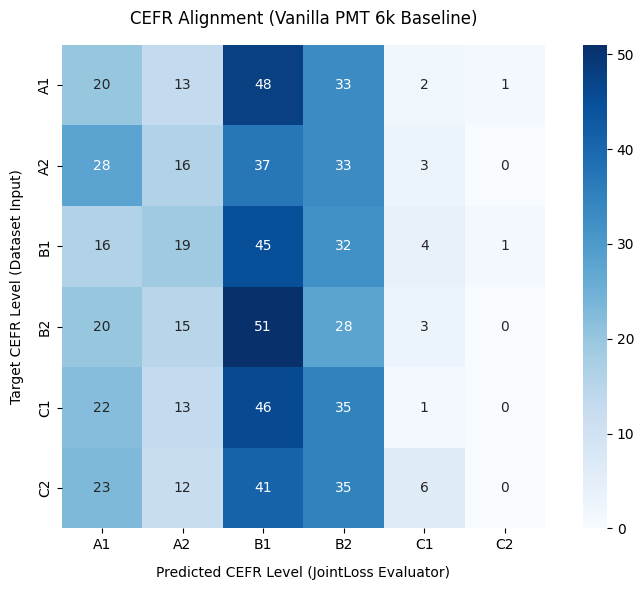

In [ ]:
# ==========================================
# 4. REPORT EXPORT GENERATION
# ==========================================
y_true = df_final['target_cefr']
y_pred = df_final['predicted_cefr']

strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true.map(label_map), y_pred.map(label_map))
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (VANILLA PMT 6k BASELINE)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {len(df_final)}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "Avg Perplexity        : (Computed externally)\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true, y_pred, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Output and write the TXT file locally
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(report_text)

# Plot and export the Confusion Matrix file
cm = confusion_matrix(y_true, y_pred, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
plt.title("CEFR Alignment (Vanilla PMT 6k Baseline)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")